In [2]:
# Cell 1: Environment Setup and Library Imports
# Install necessary packages (Execute this block in a Colab cell)
!pip install -q kagglehub grad-cam scikit-learn
import os
import glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import kagglehub

# Explainable AI (XAI) Imports for Visual Heatmaps
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
# Enforce deterministic behavior by setting random seeds
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Download the latest version of the Shenzhen TB Dataset via KaggleHub
print("Initiating dataset download sequence...")
path = kagglehub.dataset_download("raddar/tuberculosis-chest-xrays-shenzhen")
print("Path to dataset files:", path)

# Dynamically locate the directory containing the PNG files
# The dataset typically separates clinical readings from 'CXR_png'
image_dir = None
for root, dirs, files in os.walk(path):
    if any(f.endswith('.png') for f in files):
        image_dir = root
        break

if image_dir is None:
    raise FileNotFoundError("Critical Error: Could not locate PNG images within the downloaded dataset.")

print(f"Radiographic image directory successfully located at: {image_dir}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Initiating dataset download sequence...


100%|██████████| 3.51G/3.51G [00:18<00:00, 209MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/raddar/tuberculosis-chest-xrays-shenzhen/versions/1
Radiographic image directory successfully located at: /root/.cache/kagglehub/datasets/raddar/tuberculosis-chest-xrays-shenzhen/versions/1/images/images


In [5]:
# Cell 2: Dataset Definition and Preprocessing Pipelines

class ShenzhenTuberculosisDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_paths = glob.glob(os.path.join(image_dir, "*.png"))
        self.transform = transform
        self.data = [] # Fixed: Added empty list

        for img_path in self.image_paths:
            filename = os.path.basename(img_path)
            try:
                # Fixed: Added to isolate the number from the extension
                label_str = filename.split('_')[-1].split('.')
                label = int(label_str[0]) # Fixed: Added [0] to get the label number
                # Fixed: Added for binary validation bounds
                if label in [0, 1]: # Fixed: Added [0, 1] for binary validation bounds
                    self.data.append((img_path, label))
            except Exception as e:
                continue

        print(f"Data ingestion complete. Successfully loaded {len(self.data)} verified images.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# ImageNet Normalization Constants
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224 pixels
    transforms.RandomHorizontalFlip(), # Apply random horizontal flip for augmentation
    transforms.RandomRotation(10), # Apply random rotation up to 10 degrees
    transforms.ToTensor(), # Convert PIL Image to PyTorch Tensor
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std) # Normalize with ImageNet stats
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224 pixels
    transforms.ToTensor(), # Convert PIL Image to PyTorch Tensor
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std) # Normalize with ImageNet stats
])

full_dataset = ShenzhenTuberculosisDataset(image_dir=image_dir, transform=None)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

train_ds.dataset.transform = train_transforms
val_ds.dataset.transform = val_transforms

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Data ingestion complete. Successfully loaded 662 verified images.


In [6]:
# Cell 3: Neural Network Architecture Configuration

# Probe computational backend for GPU acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Computational Backend assigned to: {device}")

# Initialize ResNet50 framework utilizing ImageNet foundational weights
model = models.resnet50(pretrained=True)

# Phase 1 Transfer Learning: Freeze foundational feature extraction layers
for param in model.parameters():
    param.requires_grad = False

# Phase 2 Fine-Tuning: Unfreeze the final convolutional block (layer4)
# to adapt high-level semantic abstractions to TB pathology
for param in model.layer4.parameters():
    param.requires_grad = True

# Modify the fully connected topological head for binary diagnostic output
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5), # Stochastic regularization to mitigate overfitting
    nn.Linear(num_ftrs, 1) # Singular logit output representing TB probability
)

# Offload the architecture to the VRAM
model = model.to(device)

# Formulate the optimization strategy based on empirical literature
LEARNING_RATE = 0.001
criterion = nn.BCEWithLogitsLoss() # Numerically stable combined Sigmoid + BCE

# The optimizer strictly acts upon unfrozen, dynamically tracked parameters
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

Computational Backend assigned to: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 49.8MB/s]


In [8]:
# Cell 4: Deep Learning Training Loop and Statistical Validation

EPOCHS = 10
best_f1_score = 0.0

print("\nCommencing Training Sequence...")

for epoch in range(EPOCHS):
    # Enable Gradient Tracking
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        # Load batch to GPU and unsqueeze labels to match output dimensionality
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad() # Flush residual gradients

        outputs = model(images) # Forward inference
        loss = criterion(outputs, labels) # Error calculation

        loss.backward() # Propagate gradients backward
        optimizer.step() # Update topological weights

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation Phase Setup
    model.eval()
    val_loss = 0.0
    all_predictions = []
    all_ground_truths = []

    # Disable gradient calculus to conserve memory and accelerate inference
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

            # Apply Sigmoid scalar transformation to extract normalized probabilities
            probabilities = torch.sigmoid(outputs)
            # Threshold classification boundary at 0.5
            predictions = (probabilities > 0.5).float()

            all_predictions.extend(predictions.cpu().numpy())
            all_ground_truths.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)

    # Exhaustive Statistical Computation
    acc = accuracy_score(all_ground_truths, all_predictions)
    f1 = f1_score(all_ground_truths, all_predictions)
    prec = precision_score(all_ground_truths, all_predictions, zero_division=0)
    rec = recall_score(all_ground_truths, all_predictions, zero_division=0)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

    # Save the architecture possessing the highest diagnostic harmony
    if f1 > best_f1_score:
        best_f1_score = f1
        torch.save(model.state_dict(), 'optimized_tb_resnet50.pth')
        print("  -> Topologically superior model identified and saved.")

print(f"\nOptimization Complete. Peak Validation F1-Score achieved: {best_f1_score:.4f}")


Commencing Training Sequence...
Epoch 1/10 | Train Loss: 0.4728 | Val Loss: 0.4680 | Acc: 0.8195 | F1: 0.8000 | Prec: 0.9796 | Rec: 0.6761
  -> Topologically superior model identified and saved.
Epoch 2/10 | Train Loss: 0.2343 | Val Loss: 0.3040 | Acc: 0.9173 | F1: 0.9197 | Prec: 0.9545 | Rec: 0.8873
  -> Topologically superior model identified and saved.
Epoch 3/10 | Train Loss: 0.1431 | Val Loss: 1.4344 | Acc: 0.7895 | F1: 0.7586 | Prec: 0.9778 | Rec: 0.6197
Epoch 4/10 | Train Loss: 0.1087 | Val Loss: 1.1690 | Acc: 0.7368 | F1: 0.6789 | Prec: 0.9737 | Rec: 0.5211
Epoch 5/10 | Train Loss: 0.0954 | Val Loss: 0.5273 | Acc: 0.8571 | F1: 0.8742 | Prec: 0.8250 | Rec: 0.9296
Epoch 6/10 | Train Loss: 0.1075 | Val Loss: 0.6392 | Acc: 0.8120 | F1: 0.8344 | Prec: 0.7875 | Rec: 0.8873
Epoch 7/10 | Train Loss: 0.0843 | Val Loss: 0.6734 | Acc: 0.8496 | F1: 0.8611 | Prec: 0.8493 | Rec: 0.8732
Epoch 8/10 | Train Loss: 0.0366 | Val Loss: 0.6763 | Acc: 0.8947 | F1: 0.8955 | Prec: 0.9524 | Rec: 0.8451

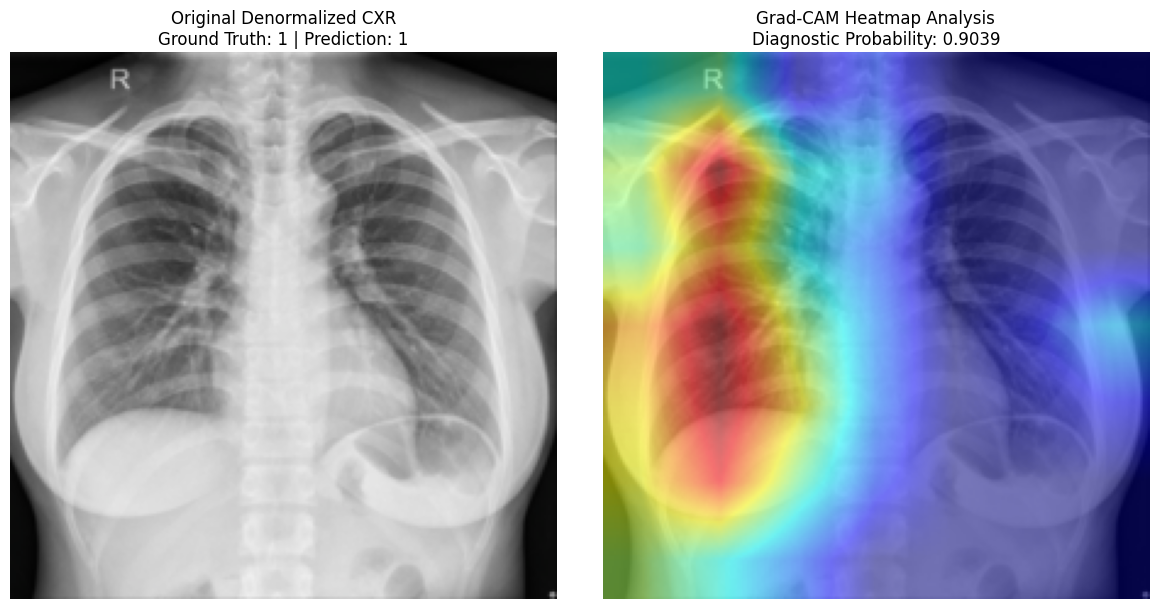

In [10]:
# Cell 5: Grad-CAM XAI Generation and Visualization

# Instantiate the optimal model state
model.load_state_dict(torch.load('optimized_tb_resnet50.pth'))
model.eval()

# Sample extraction from the validation subset for visual interpretation
sample_idx = 0 # Adjust index to probe disparate clinical cases
sample_image_tensor, sample_label = val_ds[sample_idx]
# Inject batch dimension: ->
inference_tensor = sample_image_tensor.unsqueeze(0).to(device)

# Execute forward pass to obtain target prediction
with torch.no_grad():
    raw_output = model(inference_tensor)
    probability = torch.sigmoid(raw_output).item()
    predicted_class = 1 if probability > 0.5 else 0

# Grad-CAM Configuration
# Target the final bottleneck sub-layer in ResNet50's spatial hierarchy
target_layers = [model.layer4[-1]]

# Initialize the GradCAM engine
cam_engine = GradCAM(model=model, target_layers=target_layers)

# Define the focus point for gradient calculation. For a single output neuron,
# mapping the target to class '0' computes gradients relative to the singular logit.
targets = [ClassifierOutputTarget(0)]

# Calculate the two-dimensional activation map
grayscale_heatmap = cam_engine(input_tensor=inference_tensor, targets=targets)
grayscale_heatmap = grayscale_heatmap[0, :] # Strip batch dimension

# Reconstruction of the original radiograph
# The tensor must be denormalized back to standard visual space
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(imagenet_mean, imagenet_std)],
    std=[1/s for s in imagenet_std]
)
visual_reconstruction = inv_normalize(sample_image_tensor).permute(1, 2, 0).numpy()
visual_reconstruction = np.clip(visual_reconstruction, 0, 1)

# Superimpose the thermal matrix onto the structural radiograph
fused_visualization = show_cam_on_image(visual_reconstruction, grayscale_heatmap, use_rgb=True)

# Render Analytical Plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f"Original Denormalized CXR\nGround Truth: {int(sample_label.item())} | Prediction: {predicted_class}")
plt.imshow(visual_reconstruction)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Grad-CAM Heatmap Analysis\nDiagnostic Probability: {probability:.4f}")
plt.imshow(fused_visualization)
plt.axis('off')

plt.tight_layout()
plt.show()